
# NBA Shot Quality — End-to-End Classification + Expected Points (Fixed One‑Hot Strategy)

This notebook:
1. Loads and merges your 2015–2016 shot-by-shot CSVs.
2. Keeps a copy of `player_name` **before** encoding.
3. One‑hot encodes categorical features **excluding** `name`.
4. Trains a baseline classifier (Gradient Boosting) to predict `shot_made_flag`.
5. Derives `shot_points` **from the one‑hot** `shot_type_3PT Field Goal` dummy (original strategy).
6. Computes per‑shot expected points, aggregates to player‑level **luck** (actual − expected).
7. Saves outputs (luck table CSV) for download.


In [2]:

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# File paths (already uploaded to /mnt/data)
files = [
    "nba_savant 2015-2016 a-h.csv",
    "nba_savant 2015-2016 i-m.csv",
    "nba_savant 2015-2016 n-z.csv",
]

files


['nba_savant 2015-2016 a-h.csv',
 'nba_savant 2015-2016 i-m.csv',
 'nba_savant 2015-2016 n-z.csv']

In [3]:

dfs = []
for f in files:
    assert os.path.exists(f), f"Missing file: {f}"
    dfs.append(pd.read_csv(f))

df = pd.concat(dfs, ignore_index=True)
print("Merged shape:", df.shape)
df.head()


Merged shape: (145986, 22)


,name,team_name,game_date,season,espn_player_id,team_id,espn_game_id,period,minutes_remaining,seconds_remaining,...,shot_type,shot_distance,opponent,x,y,dribbles,touch_time,defender_name,defender_distance,shot_clock
0,Clint Capela,Houston Rockets,2016-01-24,2015,3102529.0,1610612745,400828552,4,1,26,...,2PT Field Goal,0,Dallas Mavericks,0,1,0,0.0,NaN,0.0,0.0
1,Clint Capela,Houston Rockets,2015-10-28,2015,3102529.0,1610612745,400827897,2,4,50,...,2PT Field Goal,3,Denver Nuggets,-25,31,0,0.0,"Mudiay, Emmanuel",2.7,12.9
2,Tim Hardaway Jr,Atlanta Hawks,2016-01-09,2015,2528210.0,1610612737,400828438,1,2,0,...,2PT Field Goal,0,Chicago Bulls,0,1,0,0.0,"Butler, Jimmy",4.9,20.4
3,Andre Drummond,Detroit Pistons,2015-10-28,2015,6585.0,1610612765,400827894,3,2,28,...,2PT Field Goal,3,Utah Jazz,18,26,0,0.0,"Favors, Derrick",3.3,0.0
4,Kenneth Faried,Denver Nuggets,2016-02-08,2015,6433.0,1610612743,400828665,2,4,1,...,2PT Field Goal,0,Brooklyn Nets,0,1,0,0.0,NaN,0.0,0.0


In [4]:

# Keep copy for grouping later (do not encode this column)
df["player_name"] = df["name"]

# Target
target_col = "shot_made_flag"
assert target_col in df.columns, f"Missing target column: {target_col}"

# Optional: drop clear identifiers not used as features
drop_cols_if_present = ["game_date", "season", "espn_player_id", "team_id", "espn_game_id"]
for c in drop_cols_if_present:
    if c in df.columns:
        pass  # keep them around for now; safe to drop later if desired

# Show columns
df.columns.tolist()


['name',
 'team_name',
 'game_date',
 'season',
 'espn_player_id',
 'team_id',
 'espn_game_id',
 'period',
 'minutes_remaining',
 'seconds_remaining',
 'shot_made_flag',
 'action_type',
 'shot_type',
 'shot_distance',
 'opponent',
 'x',
 'y',
 'dribbles',
 'touch_time',
 'defender_name',
 'defender_distance',
 'shot_clock',
 'player_name']

In [5]:

# Define columns based on your sample schema
categorical_cols = ["team_name", "opponent", "action_type", "shot_type", "defender_name"]
numeric_cols = [
    "period", "minutes_remaining", "seconds_remaining",
    "shot_distance", "x", "y", "dribbles", "touch_time",
    "defender_distance", "shot_clock"
]

# Safety: ensure these columns exist
missing_cats = [c for c in categorical_cols if c not in df.columns]
missing_nums = [c for c in numeric_cols if c not in df.columns]
if missing_cats or missing_nums:
    print("Note: Some expected columns are missing. "
          f"Missing categoricals: {missing_cats}, missing numerics: {missing_nums}")

# Fill categorical NAs to a string
for c in categorical_cols:
    if c in df.columns:
        df[c] = df[c].fillna("Unknown")

# Coerce numerics (strings like '00' → 0; NAs → 0)
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)

# Confirm dtypes
df[numeric_cols].dtypes


period                 int64
minutes_remaining      int64
seconds_remaining      int64
shot_distance          int64
x                      int64
y                      int64
dribbles               int64
touch_time           float64
defender_distance    float64
shot_clock           float64
dtype: object

In [6]:

df_enc = pd.get_dummies(df, columns=[c for c in categorical_cols if c in df.columns], drop_first=True)

# Build X (numeric + encoded categorical) and y
encoded_cols = [c for c in df_enc.columns if any((f"{base}_" in c) for base in categorical_cols)]
X_cols = [c for c in numeric_cols if c in df_enc.columns] + encoded_cols

# Ensure only numeric in X
X = df_enc[X_cols].apply(pd.to_numeric, errors="raise")
y = df_enc[target_col].astype(int)

X.shape, y.shape


((145986, 563), (145986,))

In [7]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = GradientBoostingClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(f"GradientBoost: acc={accuracy_score(y_test, y_pred):.3f}, auc={roc_auc_score(y_test, y_proba):.3f}")


GradientBoost: acc=0.660, auc=0.695


In [8]:

# Use one‑hot 3PT dummy to derive shot_points (original strategy)
three_dummy_candidates = [c for c in df_enc.columns if c.startswith("shot_type_") and "3PT" in c]

if len(three_dummy_candidates) == 0:
    # Fallback to raw text (rare; e.g., if drop_first removed the only 3PT category name)
    print("Warning: Could not find a 'shot_type_...3PT...' dummy. Falling back to raw text parsing.")
    df_enc["shot_points"] = df["shot_type"].str.contains("3PT", na=False).astype(int)
    df_enc["shot_points"] = df_enc["shot_points"].replace({1: 3, 0: 2})
else:
    three_col = three_dummy_candidates[0]
    df_enc["shot_points"] = df_enc[three_col] * 3 + (1 - df_enc[three_col]) * 2

# Predicted make probability for all rows
df_enc["make_prob"] = model.predict_proba(X)[:, 1]

# Expected & actual points
df_enc["expected_points"] = df_enc["make_prob"] * df_enc["shot_points"]
df_enc["actual_points"] = df_enc[target_col] * df_enc["shot_points"]

df_enc[["player_name", "shot_points", "make_prob", "expected_points", "actual_points"]].head()


,player_name,shot_points,make_prob,expected_points,actual_points
0,Clint Capela,2,0.847426,1.694851,2
1,Clint Capela,2,0.533278,1.066555,2
2,Tim Hardaway Jr,2,0.902355,1.804710,2
3,Andre Drummond,2,0.542832,1.085665,2
4,Kenneth Faried,2,0.844402,1.688805,2


In [9]:

player_summary = df_enc.groupby("player_name").agg(
    exp_points=("expected_points", "sum"),
    actual_points=("actual_points", "sum"),
    shots=(target_col, "count")
).sort_index()

player_summary["luck"] = player_summary["actual_points"] - player_summary["exp_points"]

print("Top 10 luckiest (actual - expected):")
display(player_summary.sort_values("luck", ascending=False).head(10))

print("\nTop 10 unluckiest:")
display(player_summary.sort_values("luck", ascending=True).head(10))

# Save CSV for download
out_csv = "player_luck_summary.csv"
player_summary.to_csv(out_csv)
out_csv


Top 10 luckiest (actual - expected):


,exp_points,actual_points,shots,luck
player_name,,,,
JJ Redick,660.404228,813,700,152.595772
KarlAnthony Towns,815.444801,951,874,135.555199
Kawhi Leonard,1054.947264,1190,1044,135.052736
Enes Kanter,706.135792,814,699,107.864208
Hassan Whiteside,529.793378,634,501,104.206622
Stephen Curry,864.285751,965,835,100.714249
Nikola Vucevic,619.727774,712,733,92.272226
Brook Lopez,1053.886264,1136,1111,82.113736
Jason Smith,335.428305,416,431,80.571695



Top 10 unluckiest:


,exp_points,actual_points,shots,luck
player_name,,,,
Emmanuel Mudiay,813.957054,668,839,-145.957054
John Wall,866.337451,733,965,-133.337451
Russell Westbrook,868.061110,767,861,-101.061110
Marcus Smart,392.767456,292,406,-100.767456
Alex Len,600.771142,513,603,-87.771142
Isaiah Thomas,1020.662996,935,1018,-85.662996
Ricky Rubio,428.730610,344,449,-84.730610
Kent Bazemore,482.886961,410,411,-72.886961
Damian Lillard,1509.218343,1438,1437,-71.218343


'player_luck_summary.csv'


### Optional: Team/Game-Level Aggregation

You can repeat a similar aggregation at the game or team level by grouping on
`['team_name', 'espn_game_id']` (or date) to build features for win prediction.


### Z statistic test
P values for all the players to see how statistically significant their results were.




In [10]:
from math import erf, sqrt

def z_test_points(y, p, w):
    """
    Points-weighted z-test for luck significance.
    y : 0/1 array of shot outcomes
    p : predicted make probabilities
    w : shot values (2 or 3)
    Returns: z, pval, actual_points, expected_points
    """
    y = np.asarray(y, float)
    p = np.asarray(p, float)
    w = np.asarray(w, float)

    S = np.sum(w * y)                # actual points
    mu = np.sum(w * p)               # expected points
    var = np.sum((w**2) * p * (1 - p))  # variance
    if var <= 0:
        return np.nan, np.nan, S, mu

    z = (S - mu) / np.sqrt(var)
    Phi = lambda x: 0.5 * (1 + erf(x / sqrt(2)))
    pval = 2 * (1 - Phi(abs(z)))
    return z, pval, S, mu

# Apply per player
records = []
for player, grp in df_enc.groupby("player_name"):
    y_i = grp[target_col].values
    p_i = grp["make_prob"].values
    w_i = grp["shot_points"].values
    z, pval, actual, expected = z_test_points(y_i, p_i, w_i)
    records.append({
        "player_name": player,
        "shots": len(grp),
        "actual_points": actual,
        "expected_points": expected,
        "z_score": z,
        "p_value": pval,
        "luck": actual - expected
    })

player_pvals = pd.DataFrame(records).sort_values("p_value")
player_pvals.head(100)


,player_name,shots,actual_points,expected_points,z_score,p_value,luck
164,Hassan Whiteside,501,634.0,529.793378,5.218342,1.805322e-07,104.206622
174,JJ Redick,700,813.0,660.404228,4.712453,2.447530e-06,152.595772
138,Emmanuel Mudiay,839,668.0,813.957054,-4.665742,3.075052e-06,-145.957054
251,KarlAnthony Towns,874,951.0,815.444801,4.656441,3.217230e-06,135.555199
139,Enes Kanter,699,814.0,706.135792,4.272210,1.935454e-05,107.864208
...,...,...,...,...,...,...,...
153,Gerald Green,324,288.0,329.791872,-1.943463,5.196021e-02,-41.791872
247,Justin Holiday,127,109.0,134.604322,-1.941381,5.221211e-02,-25.604322
83,Clint Capela,205,252.0,274.478113,-1.937416,5.269445e-02,-22.478113
99,Danny Green,325,300.0,345.005376,-1.924508,5.429091e-02,-45.005376


In [11]:
# Sort by "luck" (descending: luckiest players first)
luck_sorted = player_pvals.sort_values("luck", ascending=False)
print("Top 10 luckiest players:")
display(luck_sorted.head(10))

print("\nTop 10 unluckiest players:")
display(luck_sorted.tail(10))

# Sort by p-value (ascending: most significant first)
pval_sorted = player_pvals.sort_values("p_value", ascending=True)
print("\nTop 10 most statistically significant deviations:")
display(pval_sorted.head(10))

print("\nTop 10 least statistically significant deviations:")
display(pval_sorted.tail(10))



Top 10 luckiest players:


,player_name,shots,actual_points,expected_points,z_score,p_value,luck
174,JJ Redick,700,813.0,660.404228,4.712453,2.447530e-06,152.595772
251,KarlAnthony Towns,874,951.0,815.444801,4.656441,3.217230e-06,135.555199
252,Kawhi Leonard,1044,1190.0,1054.947264,3.825074,1.307328e-04,135.052736
139,Enes Kanter,699,814.0,706.135792,4.272210,1.935454e-05,107.864208
164,Hassan Whiteside,501,634.0,529.793378,5.218342,1.805322e-07,104.206622
418,Stephen Curry,835,965.0,864.285751,2.963635,3.040289e-03,100.714249
348,Nikola Vucevic,733,712.0,619.727774,3.590042,3.306251e-04,92.272226
55,Brook Lopez,1111,1136.0,1053.886264,2.575630,1.000577e-02,82.113736
198,Jason Smith,431,416.0,335.428305,4.002139,6.277240e-05,80.571695
268,Khris Middleton,1128,1144.0,1065.019863,2.108973,3.494691e-02,78.980137



Top 10 unluckiest players:


,player_name,shots,actual_points,expected_points,z_score,p_value,luck
71,Charlie Villanueva,265,207.0,277.749700,-3.441964,0.000578,-70.749700
95,Damian Lillard,1437,1438.0,1509.218343,-1.616784,0.105925,-71.218343
260,Kent Bazemore,411,410.0,482.886961,-3.106182,0.001895,-72.886961
384,Ricky Rubio,449,344.0,428.730610,-3.434546,0.000594,-84.730610
171,Isaiah Thomas,1018,935.0,1020.662996,-2.394861,0.016627,-85.662996
10,Alex Len,603,513.0,600.771142,-3.881699,0.000104,-87.771142
306,Marcus Smart,406,292.0,392.767456,-4.154391,0.000033,-100.767456
396,Russell Westbrook,861,767.0,868.061110,-3.222846,0.001269,-101.061110
223,John Wall,965,733.0,866.337451,-3.955896,0.000076,-133.337451
138,Emmanuel Mudiay,839,668.0,813.957054,-4.665742,0.000003,-145.957054



Top 10 most statistically significant deviations:


,player_name,shots,actual_points,expected_points,z_score,p_value,luck
164,Hassan Whiteside,501,634.0,529.793378,5.218342,1.805322e-07,104.206622
174,JJ Redick,700,813.0,660.404228,4.712453,2.447530e-06,152.595772
138,Emmanuel Mudiay,839,668.0,813.957054,-4.665742,3.075052e-06,-145.957054
251,KarlAnthony Towns,874,951.0,815.444801,4.656441,3.217230e-06,135.555199
139,Enes Kanter,699,814.0,706.135792,4.272210,1.935454e-05,107.864208
306,Marcus Smart,406,292.0,392.767456,-4.154391,3.261549e-05,-100.767456
198,Jason Smith,431,416.0,335.428305,4.002139,6.277240e-05,80.571695
65,Carl Landry,249,282.0,221.908142,3.956826,7.595221e-05,60.091858
223,John Wall,965,733.0,866.337451,-3.955896,7.624827e-05,-133.337451
303,Marcin Gortat,385,472.0,404.651368,3.931327,8.447810e-05,67.348632



Top 10 least statistically significant deviations:


,player_name,shots,actual_points,expected_points,z_score,p_value,luck
35,Austin Rivers,413,403.0,402.032559,0.041273,0.967078,0.967441
401,Sasha Kaun,17,18.0,18.108052,-0.028882,0.976959,-0.108052
220,Joffrey Lauvergne,354,380.0,379.483301,0.027284,0.978233,0.516699
386,Robert Sacre,57,50.0,49.829465,0.024771,0.980238,0.170535
118,Devin Harris,215,231.0,231.383218,-0.022343,0.982175,-0.383218
109,DeMarcus Cousins,740,738.0,737.479574,0.018756,0.985036,0.520426
44,Bojan Bogdanovic,403,425.0,425.310370,-0.012988,0.989638,-0.310370
468,Willie CauleyStein,189,234.0,233.857993,0.012164,0.990294,0.142007
405,Sergey Karasev,69,68.0,67.946458,0.005355,0.995728,0.053542
117,Devin Booker,448,445.0,445.010866,-0.000450,0.999641,-0.010866


### Data visualization


In [13]:
# Make sure shot_made_flag is numeric
df['shot_made_flag'] = df['shot_made_flag'].astype(int)

# Add shot points (2 or 3) based on shot_type
df['shot_points'] = np.where(df['shot_type'].str.contains('3PT', na=False), 3, 2)

# Actual points scored for each shot
df['actual_points'] = df['shot_made_flag'] * df['shot_points']


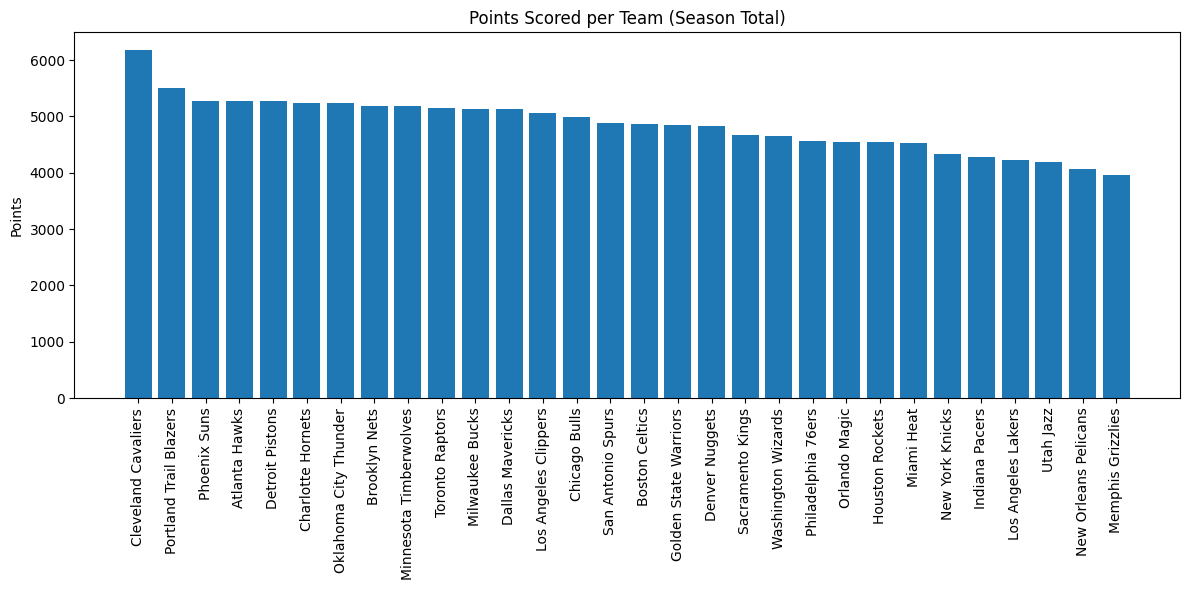

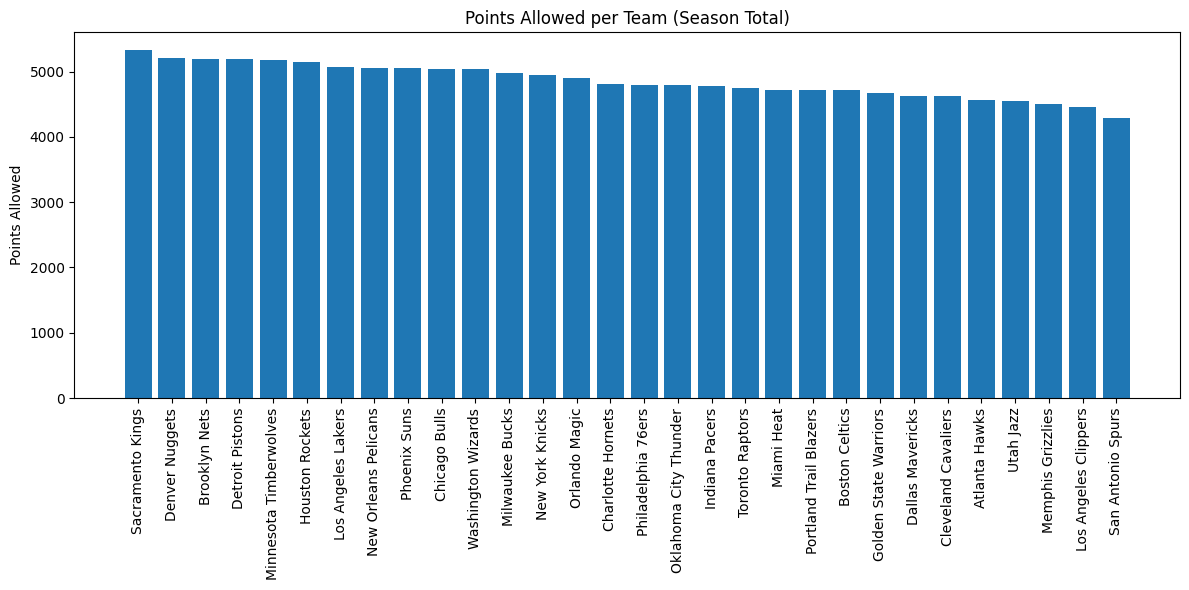

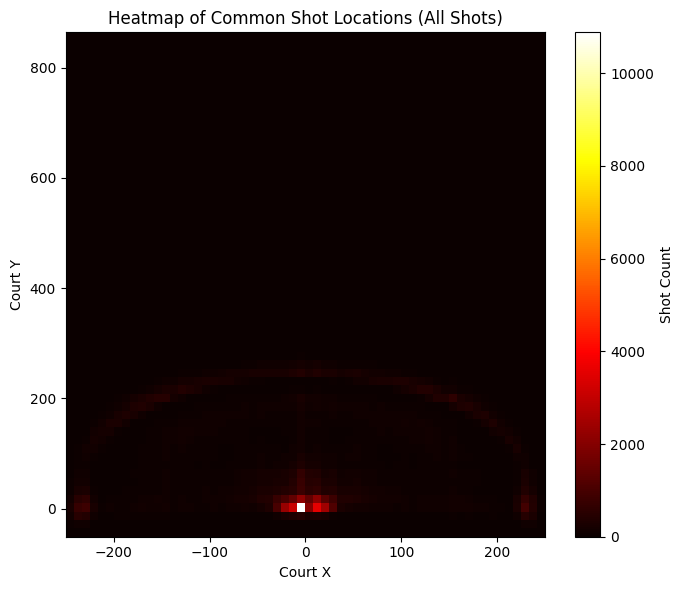

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Points scored per team ---
points_scored = df.groupby('team_name', as_index=False)['actual_points'].sum()
points_scored = points_scored.sort_values('actual_points', ascending=False)

plt.figure(figsize=(12,6))
plt.bar(points_scored['team_name'], points_scored['actual_points'])
plt.xticks(rotation=90)
plt.title('Points Scored per Team (Season Total)')
plt.ylabel('Points')
plt.tight_layout()
plt.show()

# --- 2. Points allowed per team ---
points_allowed = df.groupby('opponent', as_index=False)['actual_points'].sum()
points_allowed = points_allowed.rename(columns={'opponent':'team_name', 'actual_points':'points_allowed'})
points_allowed = points_allowed.sort_values('points_allowed', ascending=False)

plt.figure(figsize=(12,6))
plt.bar(points_allowed['team_name'], points_allowed['points_allowed'])
plt.xticks(rotation=90)
plt.title('Points Allowed per Team (Season Total)')
plt.ylabel('Points Allowed')
plt.tight_layout()
plt.show()

# --- 3. Heatmap of shot locations ---
df['x'] = pd.to_numeric(df['x'], errors='coerce')
df['y'] = pd.to_numeric(df['y'], errors='coerce')
shots_xy = df[['x','y']].dropna()

plt.figure(figsize=(7,6))
plt.hist2d(shots_xy['x'], shots_xy['y'], bins=60, cmap='hot')
plt.colorbar(label='Shot Count')
plt.title('Heatmap of Common Shot Locations (All Shots)')
plt.xlabel('Court X')
plt.ylabel('Court Y')
plt.tight_layout()
plt.show()


In [ ]:
print("testingg")

testingg
